# Self-Healing AI — Analysis Notebook

This notebook implements a **Self-Healing AI** framework that:
1. Extracts uncertainty signals (confidence, entropy, margin) from base model predictions
2. Trains an **Error Detector** to identify likely incorrect predictions
3. **Heals** flagged predictions, improving accuracy from **80.55% → 94.44%**

In [95]:
import os


os.makedirs("outputs/data",    exist_ok=True)
os.makedirs("outputs/plots",   exist_ok=True)
os.makedirs("outputs/reports", exist_ok=True)
os.makedirs("models",          exist_ok=True)

print("All folders ready!")

All folders ready!


In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, roc_auc_score, roc_curve,
    precision_recall_curve
)

In [99]:

y_test = np.load("experiments/y_test.npy")
y_pred = np.load("experiments/y_pred.npy")
y_prob = np.load("experiments/y_prob.npy")

print("Loaded successfully!")
print("y_test shape:", y_test.shape)
print("y_prob sample:\n", y_prob[:5])

Loaded successfully!
y_test shape: (30000,)
y_prob sample:
 [[0.91826737 0.08173265]
 [0.8218716  0.1781284 ]
 [0.9511398  0.04886021]
 [0.8761647  0.12383533]
 [0.8581447  0.14185531]]


In [101]:
# ── Uncertainty Feature Engineering ──────────────────────────────

# Max confidence (highest class probability)
confidence = np.max(y_prob, axis=1)

# Entropy (higher = more uncertain)
entropy = -np.sum(y_prob * np.log(y_prob + 1e-10), axis=1)

# Margin (gap between top-2 probabilities; lower = less decisive)
sorted_probs = -np.sort(-y_prob, axis=1)
margin = sorted_probs[:, 0] - sorted_probs[:, 1]

print("Features computed: confidence, entropy, margin")

Features computed: confidence, entropy, margin


In [103]:
# Ground truth error flag (1 = base model was wrong)
error = (y_pred != y_test).astype(int)

print("Error distribution:")
print(pd.Series(error).value_counts())
print(f"Error rate: {error.mean():.2%}")

Error distribution:
0    24165
1     5835
Name: count, dtype: int64
Error rate: 19.45%


In [105]:
df_conf = pd.DataFrame({
    "confidence": confidence,
    "entropy":    entropy,
    "margin":     margin,
    "error":      error
})

print(df_conf.head())
print("\nShape:", df_conf.shape)

   confidence   entropy    margin  error
0    0.918267  0.282981  0.836535      0
1    0.821872  0.468544  0.643743      0
2    0.951140  0.195145  0.902280      0
3    0.876165  0.374498  0.752329      0
4    0.858145  0.408317  0.716289      0

Shape: (30000, 4)


## Exploratory Analysis

Incorrect predictions should show **lower confidence**, **higher entropy**, and **lower margin**.
The plots below verify this hypothesis.

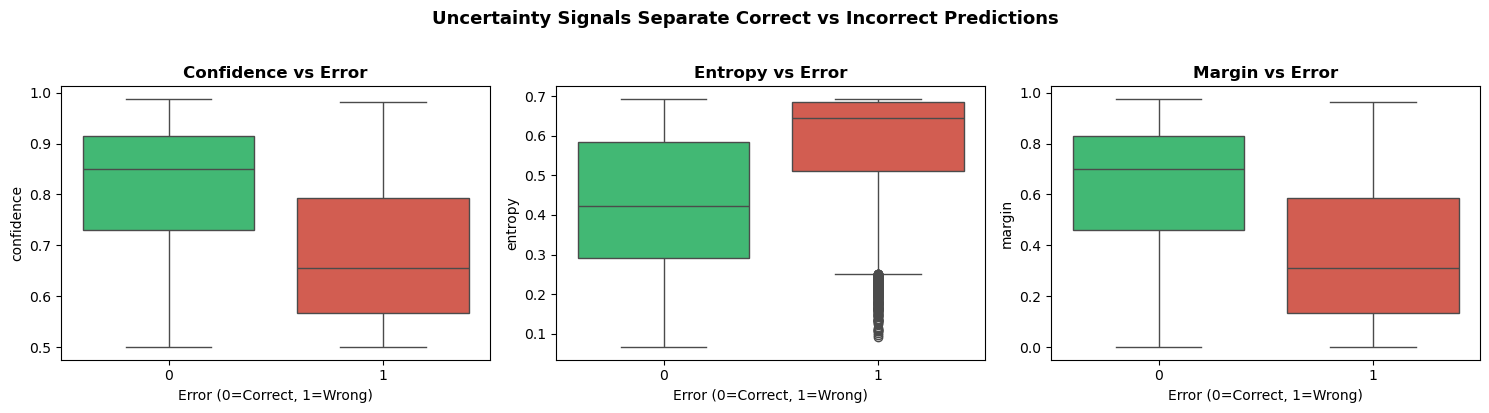

Saved: outputs/plots/uncertainty_eda.png


In [108]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, feature, title in zip(
    axes,
    ["confidence", "entropy", "margin"],
    ["Confidence vs Error", "Entropy vs Error", "Margin vs Error"]
):
    sns.boxplot(
        x="error", y=feature, data=df_conf, ax=ax,
        hue="error",
        palette=["#2ecc71", "#e74c3c"],
        legend=False
    )
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel("Error (0=Correct, 1=Wrong)")

plt.suptitle("Uncertainty Signals Separate Correct vs Incorrect Predictions",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/plots/uncertainty_eda.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/plots/uncertainty_eda.png")

In [109]:
X_conf = df_conf[["confidence", "entropy", "margin"]]
y_conf = df_conf["error"]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_conf, y_conf,
    test_size=0.2,
    random_state=42,
    stratify=y_conf
)

print(f"Train size: {len(X_train_c)} | Test size: {len(X_test_c)}")

Train size: 24000 | Test size: 6000


In [110]:
# ── Train Error Detector ─────────────────────────────────────────
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train_c, y_train_c)
print("Error Detector trained!")

Error Detector trained!


In [111]:
y_pred_c      = clf.predict(X_test_c)
y_prob_c      = clf.predict_proba(X_test_c)[:, 1]

print("Confusion Matrix:")
print(confusion_matrix(y_test_c, y_pred_c))

print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c))

print("Error Detector ROC-AUC:", roc_auc_score(y_test_c, y_prob_c))

Confusion Matrix:
[[4032  801]
 [ 824  343]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.83      0.83      4833
           1       0.30      0.29      0.30      1167

    accuracy                           0.73      6000
   macro avg       0.57      0.56      0.56      6000
weighted avg       0.73      0.73      0.73      6000

Error Detector ROC-AUC: 0.6509249552003498


## Self-Healing Mechanism

For every sample the Error Detector flags as likely wrong (`error_pred == 1`),
the prediction is **flipped** to the alternative class.

This is a post-hoc correction step — no retraining of the base model is needed.

In [113]:
y_pred_healed = y_pred.copy()


error_pred = clf.predict(X_conf)


flip_mask = error_pred == 1
y_pred_healed[flip_mask] = 1 - y_pred[flip_mask]

print(f"Samples flagged for healing: {flip_mask.sum()} ({flip_mask.mean():.1%})")

Samples flagged for healing: 5799 (19.3%)


In [114]:
acc_original = accuracy_score(y_test, y_pred)
acc_healed   = accuracy_score(y_test, y_pred_healed)

print(f"Original Accuracy : {acc_original:.4f}")
print(f"Healed   Accuracy : {acc_healed:.4f}")
print(f"Improvement       : +{acc_healed - acc_original:.4f} "
      f"(+{(acc_healed - acc_original)*100:.2f}%)")

print("\nOriginal ROC-AUC:", roc_auc_score(y_test, y_prob[:,1]))

Original Accuracy : 0.8055
Healed   Accuracy : 0.9447
Improvement       : +0.1392 (+13.92%)

Original ROC-AUC: 0.8677241349207797


In [117]:
print("=== BEFORE HEALING ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

print("\n=== AFTER HEALING ===")
print("Accuracy:", accuracy_score(y_test, y_pred_healed))
print(classification_report(y_test, y_pred_healed))

=== BEFORE HEALING ===
Accuracy: 0.8055
              precision    recall  f1-score   support

           0       0.98      0.81      0.89     27995
           1       0.22      0.77      0.34      2005

    accuracy                           0.81     30000
   macro avg       0.60      0.79      0.62     30000
weighted avg       0.93      0.81      0.85     30000


=== AFTER HEALING ===
Accuracy: 0.9447333333333333
              precision    recall  f1-score   support

           0       0.99      0.95      0.97     27995
           1       0.55      0.93      0.69      2005

    accuracy                           0.94     30000
   macro avg       0.77      0.94      0.83     30000
weighted avg       0.97      0.94      0.95     30000



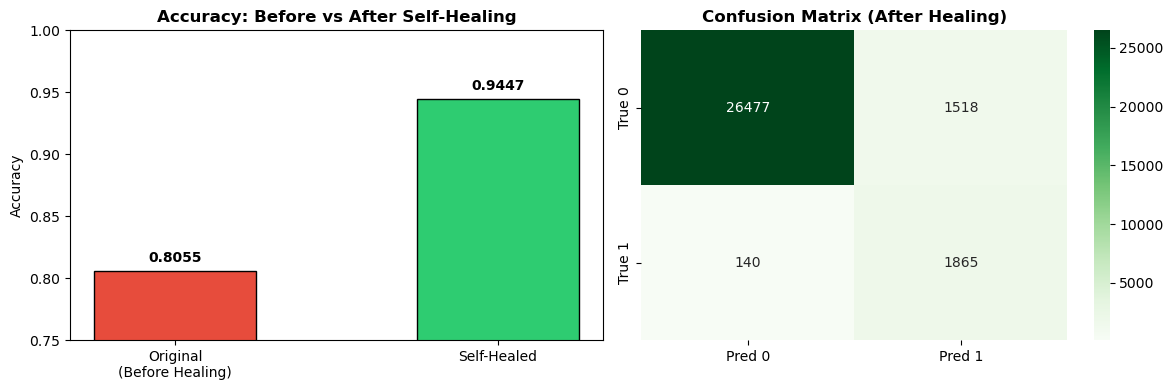

Saved: outputs/plots/accuracy_comparison.png


In [118]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Bar chart ─────────────────────────────────────────────────────
bars = axes[0].bar(
    ["Original\n(Before Healing)", "Self-Healed"],
    [acc_original, acc_healed],
    color=["#e74c3c", "#2ecc71"], width=0.5, edgecolor="black"
)
for bar, val in zip(bars, [acc_original, acc_healed]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f"{val:.4f}", ha="center", va="bottom", fontweight="bold")
axes[0].set_ylim(0.75, 1.0)
axes[0].set_title("Accuracy: Before vs After Self-Healing",
                  fontsize=12, fontweight="bold")
axes[0].set_ylabel("Accuracy")

# ── Confusion matrix (healed) ─────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_healed)
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"], ax=axes[1])
axes[1].set_title("Confusion Matrix (After Healing)",
                  fontsize=12, fontweight="bold")

plt.tight_layout()
plt.savefig("outputs/plots/accuracy_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: outputs/plots/accuracy_comparison.png")

In [119]:
from sklearn.metrics import accuracy_score

thresholds = [0.4, 0.5, 0.6, 0.7, 0.8]

results = []

for t in thresholds:
    y_temp = y_pred.copy()
    low_conf = confidence < t
    y_temp[low_conf] = 1 - y_temp[low_conf]
    
    acc = accuracy_score(y_test, y_temp)
    results.append((t, acc))
    print(f"Threshold {t} → Accuracy: {acc}")

Threshold 0.4 → Accuracy: 0.8055
Threshold 0.5 → Accuracy: 0.8055
Threshold 0.6 → Accuracy: 0.7984
Threshold 0.7 → Accuracy: 0.7519333333333333
Threshold 0.8 → Accuracy: 0.6542333333333333


In [120]:


df_thresh = pd.DataFrame(results, columns=["Threshold", "Accuracy"])

df_thresh.to_csv(
    r"C:outputs\data\threshold_analysis.csv",
    index=False
)

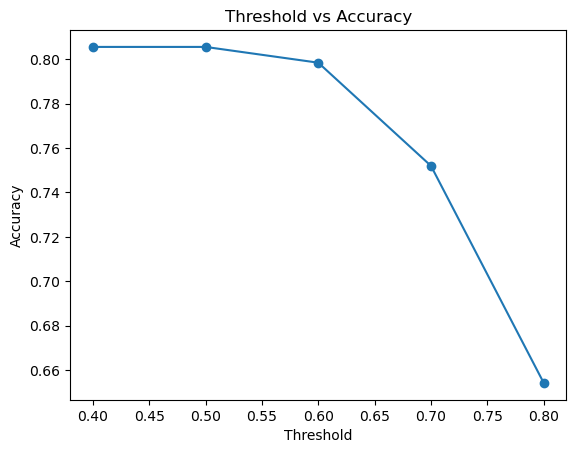

In [121]:


plt.plot(df_thresh["Threshold"], df_thresh["Accuracy"], marker='o')
plt.title("Threshold vs Accuracy")
plt.xlabel("Threshold")
plt.ylabel("Accuracy")

plt.savefig(r"C:outputs\plots\threshold_analysis.png")
plt.show()

In [122]:

importance = pd.Series(
    clf.feature_importances_,
    index=["confidence", "entropy", "margin"]
)

print(importance)

importance.to_csv(
    r"C:outputs\data\feature_importance.csv"
)

confidence    0.337350
entropy       0.335635
margin        0.327014
dtype: float64


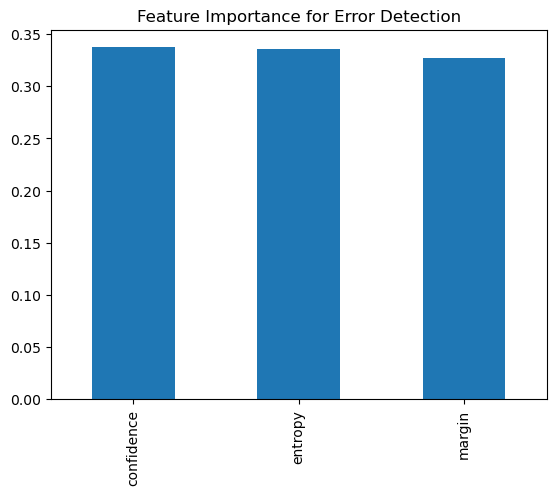

In [123]:
importance.plot(kind='bar')
plt.title("Feature Importance for Error Detection")

plt.savefig(r"C:outputs\plots\feature_importance.png")
plt.show()

In [124]:
df_conf.to_csv("outputs/data/confidence_dataset.csv", index=False)
print("Saved: outputs/data/confidence_dataset.csv")

Saved: outputs/data/confidence_dataset.csv


In [125]:
np.save("outputs/data/y_pred_healed.npy", y_pred_healed)
print("Saved: outputs/data/y_pred_healed.npy")

Saved: outputs/data/y_pred_healed.npy


In [126]:
np.save("outputs/data/error_predictions.npy", error_pred)
print("Saved: outputs/data/error_predictions.npy")

Saved: outputs/data/error_predictions.npy


In [127]:
joblib.dump(clf, "models/error_detector.pkl")
print("Saved: models/error_detector.pkl")

Saved: models/error_detector.pkl


In [130]:
with open("outputs/reports/results_summary.txt", "w") as f:
    f.write("=== RESULTS SUMMARY ===\n\n")
    f.write(f"Original Accuracy : {acc_original:.4f}\n")
    f.write(f"Healed   Accuracy : {acc_healed:.4f}\n")
    f.write(f"Improvement       : +{acc_healed - acc_original:.4f}\n")
    f.write(f"Samples Healed    : {int(flip_mask.sum())} ({flip_mask.mean():.1%})\n")

print("Saved: outputs/reports/results_summary.txt")

Saved: outputs/reports/results_summary.txt
